In [2]:
import tensorflow as tf


In [3]:
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
fashion_mnist

((array([[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         ...,
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0

In [5]:
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist

In [6]:
X_Train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]

In [7]:
print(X_Train.shape)
print(X_Train.dtype)

(55000, 28, 28)
uint8


In [8]:
X_Train[0:5]

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
   

In [9]:
X_Train, X_valid, X_test = X_Train/255.0, X_valid/255.0, X_test/255.0

In [10]:
y_train[0:10]

array([9, 0, 0, 3, 0, 2, 7, 2, 5, 5], dtype=uint8)

In [11]:
# To Convert numerical label to class name
class_names = ["T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

In [12]:
class_names[y_train[5]]

'Pullover'

In [44]:
tf.random.set_seed(42)      # Random init weights will be the same for this seed

# Model Constructor for Sequential Keras Models -->  One Stack with sequential processing in one stack
model = tf.keras.Sequential()



In [45]:
model.add(tf.keras.layers.Input(shape=[28, 28]))
model.add(tf.keras.layers.Flatten())
# Flatten is mandatory because Dense Layers can not work with multi dimensional data --> Each Matrix Multiplikation Step is the new input value of a perceptron in a dense layer
# in This Example whe have 28*28, so 784 features per record. The weight matrix will hold 784 rows per column (one column per record)

In [15]:
# off topic matrix multiply
import numpy as np
random_arr = np.random.rand(4,5)

In [16]:
# off topic matrix multiply
random_arr

array([[0.46998722, 0.07737004, 0.2119789 , 0.02418646, 0.68397787],
       [0.69009669, 0.18319218, 0.77418439, 0.25714611, 0.38522278],
       [0.32761   , 0.73882853, 0.22458888, 0.97202305, 0.96001812],
       [0.84201645, 0.90135122, 0.45376365, 0.43922807, 0.91714035]])

In [17]:
# off topic matrix multiply
random_arr[:,3]

array([0.02418646, 0.25714611, 0.97202305, 0.43922807])

In [46]:
# Adding hidden layes (2) and output layer withg softmax activation for multiclass classification
model.add(tf.keras.layers.Dense(300, activation="relu"))
model.add(tf.keras.layers.Dense(200, activation="relu"))
model.add(tf.keras.layers.Dense(100, activation="relu"))
model.add(tf.keras.layers.Dense(50, activation="relu"))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

In [47]:
model.summary()
# Beispiel Param Count first Dense: 784*300 + 300 (784 inputs * 300 weights + 300 Bias Terms)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 200)            │        60,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321,360 (1.23 MB)

 Trainable params: 321,360 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
hidden1 = model.layers[1]

In [22]:
hidden1.name

'dense'

In [23]:
weights, biases = hidden1.get_weights()

In [24]:
weights   # init Werte

array([[-0.06026954,  0.03918123, -0.01792506, ...,  0.03026532,
        -0.02790814, -0.0596399 ],
       [ 0.04030281,  0.05795863, -0.06207426, ...,  0.0130974 ,
        -0.0298265 ,  0.05846912],
       [ 0.05599259, -0.06872687, -0.01317701, ...,  0.03952077,
        -0.05880157, -0.00588758],
       ...,
       [ 0.06739511, -0.0198101 , -0.003783  , ...,  0.03834633,
        -0.00325121,  0.04862584],
       [ 0.055259  , -0.03976098,  0.02664279, ...,  0.07044825,
        -0.00269935, -0.00173425],
       [-0.06560684, -0.01726275,  0.04870223, ...,  0.05438904,
        -0.05490027, -0.00420946]], dtype=float32)

In [25]:
biases    # init Werte. Daher 0

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [48]:
model.compile(loss=tf.keras.metrics.sparse_categorical_crossentropy, optimizer="sgd", metrics=[tf.keras.metrics.sparse_categorical_accuracy])      # Verlustfunktion und optimizer für die back propagation festlegen

In [49]:
learning_history = model.fit(X_Train, y_train, validation_data=(X_valid, y_valid), epochs=50)
# backpropagate with every epoch
# when we start again the model does not begin to train with init weights. It will continue to learn with the current weighs and bias terms as starting parameters

Epoch 1/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 1.1189 - sparse_categorical_accuracy: 0.6390 - val_loss: 0.4948 - val_sparse_categorical_accuracy: 0.8256
Epoch 2/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.5007 - sparse_categorical_accuracy: 0.8237 - val_loss: 0.4315 - val_sparse_categorical_accuracy: 0.8436
Epoch 3/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.4375 - sparse_categorical_accuracy: 0.8455 - val_loss: 0.4108 - val_sparse_categorical_accuracy: 0.8524
Epoch 4/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.4012 - sparse_categorical_accuracy: 0.8567 - val_loss: 0.4015 - val_sparse_categorical_accuracy: 0.8500
Epoch 5/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.3751 - sparse_categorical_accuracy: 0.8644 - val_loss: 0.3952 - val_sparse_categorical_accuracy: 0.8502
Epoch 6/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.3553 - sparse_categorical_accuracy: 0.8703 - val_loss: 0.3929 - val_sparse_categorical_accuracy:

In [50]:
# Plotting learning curve. Fit method of keras models return a history object with a history dictionary
import matplotlib.pyplot as plt
import pandas as pd

history_datafram = pd.DataFrame(learning_history.history)

In [51]:
history_datafram.head()

,loss,sparse_categorical_accuracy,val_loss,val_sparse_categorical_accuracy
0,0.769099,0.739927,0.494785,0.8256
1,0.479093,0.830764,0.431463,0.8436
2,0.425118,0.849491,0.410769,0.8524
3,0.392375,0.859800,0.401460,0.8500
4,0.368305,0.867000,0.395202,0.8502


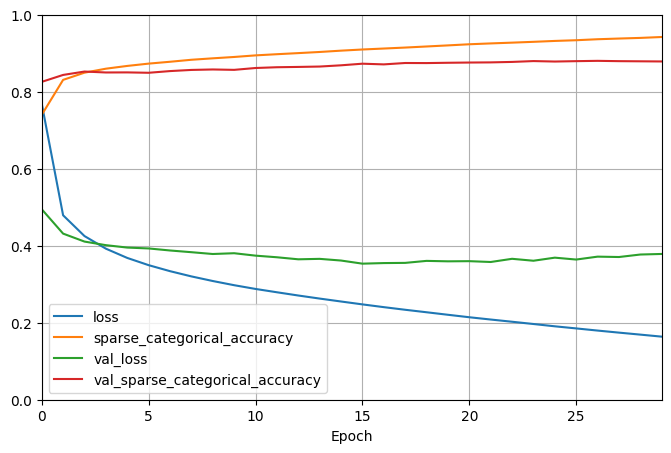

In [52]:
history_datafram.plot(grid=True, xlabel="Epoch", xlim=[0,29], ylim=[0,1], figsize=(8,5))
plt.show()

In [53]:
# Evaluate
# keras has a method for this
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5346 - sparse_categorical_accuracy: 0.8794


[0.5268168449401855, 0.8776000142097473]

In [54]:
# Predicting returns propability for one hot encoded classes
X_new = X_test[:3]
y_proba = model.predict(X_new)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step


In [60]:
y_proba.round(2)

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [61]:
y_pred = y_proba.argmax(axis=1)     # Index with the highest Value

In [62]:
y_pred

array([9, 2, 1])

In [63]:
y_test[:3]

array([9, 2, 1], dtype=uint8)

In [65]:
np.array(class_names)[y_pred]

array(['Ankle boot', 'Pullover', 'Trouser'], dtype='<U11')